In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from minimodel import data, metrics, model_builder, model_trainer

results_path_192 = './results_192-x'
results_path_192_exp = './results_192-x_exp'
results_path_192_exp_transformed_back = './results_192-x_exp_test'
results_path_192_exp_set_seed = './results_192-x_exp_test_set_seed'

output_path = './outputs'

In [2]:
def get_feve_list(results_path):
    feve_mice = []
    for mouse_id in range (6):
        file_name = "results_" + str(mouse_id) + ".npz"
        results_file_path = os.path.join(results_path, file_name)
        data = np.load(results_file_path)
        feve_mouse = data["FEVE_scores"]
        feve_mice.append(feve_mouse)
    feve_mice = np.array(feve_mice)
    return feve_mice

In [3]:
feve_mice = get_feve_list(results_path_192)
feve_mice_exp = get_feve_list(results_path_192_exp)
feve_mice_exp_transformed_back = get_feve_list(results_path_192_exp_transformed_back)
feve_mice_exp_set_seed = get_feve_list(results_path_192_exp_set_seed)
print("Feve minimodel 192 * x:")
print(feve_mice)
print()
print("Feve exp set seed 192 * x:")
print(feve_mice_exp_set_seed)
print()
print("Feve exp transformed back 192 * x:")
print(feve_mice_exp_transformed_back)
print()
print("Feve exp 192 * x:")
print(feve_mice_exp)


Feve minimodel 192 * x:
[[0.56876695 0.6935898  0.71452546 0.7104764 ]
 [0.6443211  0.73315775 0.76437044 0.75973064]
 [0.58689165 0.7208452  0.7474489  0.74623007]
 [0.5690165  0.67543244 0.71330905 0.71740633]
 [0.55430365 0.674633   0.70154774 0.7174395 ]
 [0.6027274  0.7071779  0.73927474 0.7455177 ]]

Feve exp set seed 192 * x:
[[0.56657443 0.69011153 0.70981568 0.71874248]
 [0.64241974 0.73432893 0.76488552 0.76257227]
 [0.58475381 0.72394317 0.74863559 0.73918146]
 [0.57204628 0.67427039 0.70883524 0.71904099]
 [0.55561775 0.67530107 0.7005412  0.71432126]
 [0.6006667  0.70690447 0.74150836 0.74531186]]

Feve exp transformed back 192 * x:
[[0.5683404  0.69380016 0.71620143 0.70895915]
 [0.63761325 0.73448598 0.76342132 0.76291225]
 [0.58774942 0.72055626 0.74891734 0.73672402]
 [0.56305039 0.67487788 0.70869482 0.71676767]
 [0.55803496 0.67472816 0.71084535 0.70518547]
 [0.60117233 0.71147174 0.74096888 0.74288565]]

Feve exp 192 * x:
[[0.51967454 0.65575509 0.68373647 0.6887852

In [4]:
def plot_feve_vs_depth(ax, feve_mice, title="FEVE change with model depth"):
    mean = np.mean(feve_mice, axis=0)
    sem = np.std(feve_mice, axis=0, ddof=1) / np.sqrt(feve_mice.shape[0])
    print(f"mean: {mean}")
    print(f"sem: {sem}")

    # plotting mean + SEM
    x = [1,2,3,4]
    for mice_id in range(0,6):
        ax.plot(x, feve_mice[mice_id], color="BLACK", alpha=0.3)

    ax.plot(x, mean, marker="o", markersize= 3, color="BLACK")
    ax.errorbar(x, mean, yerr=sem, capsize=4, color = "BLACK")

    # axis formatting
    ax.set_xlim(0.8,4.2)
    ax.set_xticks([1,2,3,4])
    ax.set_ylim(0.0, 0.8)

    ax.set_ylabel("FEVE")
    ax.set_xlabel("# conv layers")
    ax.set_title(title)

    # top axis with mean values
    ax_top = ax.secondary_xaxis("top")
    ax_top.set_xticks(x)
    ax_top.set_xticklabels([f"{m:.3f}" for m in mean])
    ax_top.set_xlabel("# Mean FEVE")


mean: [0.5876712  0.70080596 0.73007935 0.73280007]
sem: [0.01323539 0.00978046 0.00983083 0.00824342]
mean: [0.53060271 0.66736074 0.69184413 0.69933483]
sem: [0.01270559 0.01287916 0.00875647 0.00952131]
mean: [0.58599346 0.70165336 0.73150819 0.7289057 ]
sem: [0.01227162 0.01005861 0.00929647 0.00916671]
mean: [0.58701312 0.70080993 0.72903693 0.73319505]
sem: [0.01276562 0.01027184 0.01066823 0.00776983]


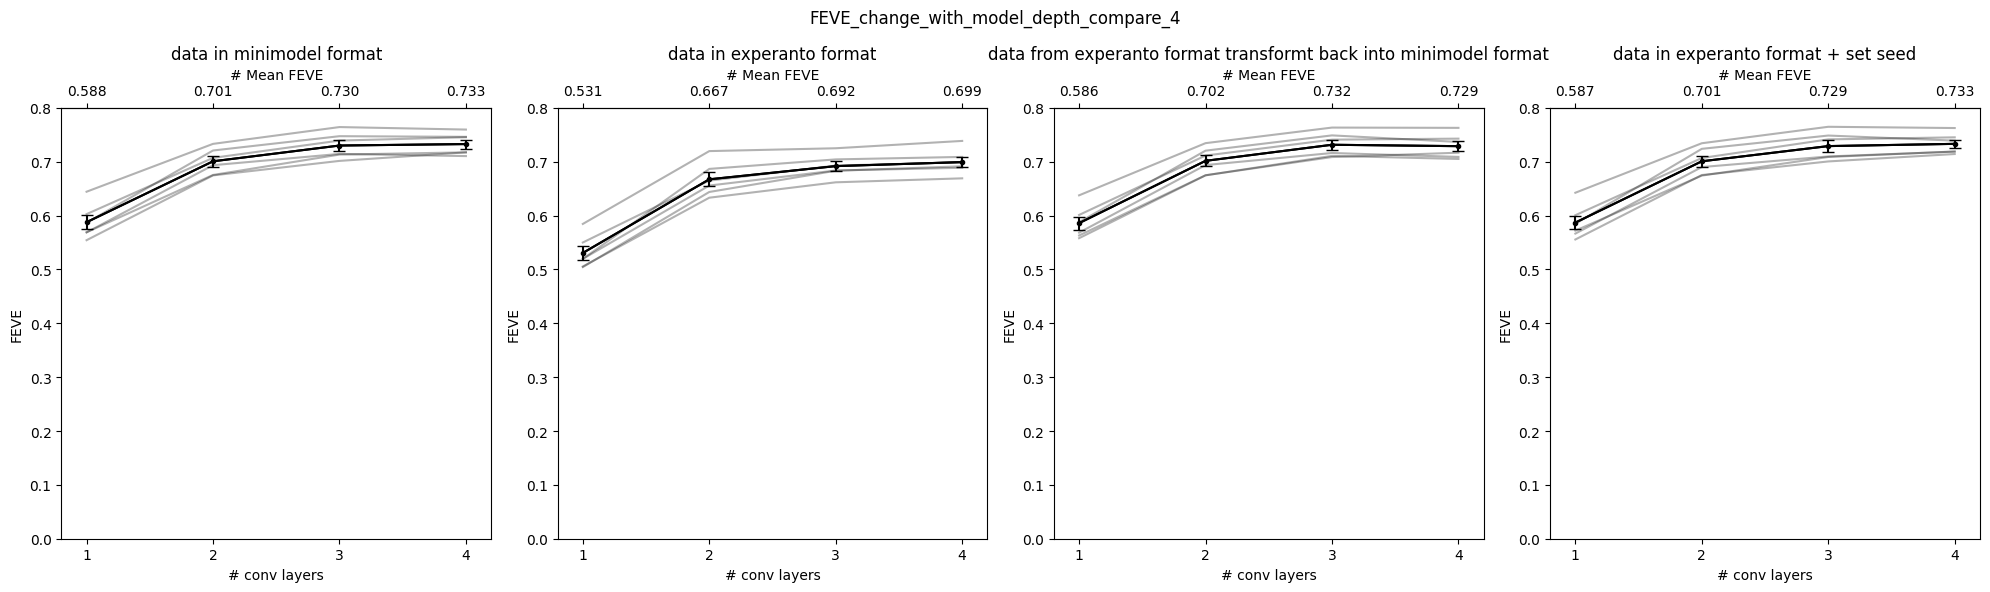

In [5]:
fig, axis = plt.subplots(1,4, figsize=(20,6))

plot_feve_vs_depth(axis[0], feve_mice, title= "data in minimodel format")
plot_feve_vs_depth(axis[1], feve_mice_exp, title= "data in experanto format")
plot_feve_vs_depth(axis[2], feve_mice_exp_transformed_back, title= "data from experanto format transformt back into minimodel format")
plot_feve_vs_depth(axis[3], feve_mice_exp_set_seed, title= "data in experanto format + set seed")

title = "FEVE_change_with_model_depth_compare_4"
fig.suptitle(title)
plt.tight_layout()
output_file_path = os.path.join(output_path, title)
plt.savefig(output_file_path)

plt.show()

In [6]:
def get_feve_list_2(results_path):
    feve_mice = []
    for mouse_id in range (6):
        file_name = "results_" + str(mouse_id) + ".npz"
        results_file_path = os.path.join(results_path, file_name)
        data = np.load(results_file_path)
        feve_mouse = data["FEVE_scores"]
        fev_mouse = data["FEV_scores"]
        threshold = 0.15
        feve_mouse = np.mean(feve_mouse[fev_mouse > threshold])
        feve_mice.append(feve_mouse)
    feve_mice = np.array(feve_mice)
    return feve_mice

In [7]:
results_path_16_320 = './results_16-320'
results_path_16_320_exp = './results_16-320_exp'
results_path_16_320_exp_transformed_back = './results_16-320_exp_test'
results_path_16_320_exp_set_seed = './results_16-320_exp_test_set_seed2'
feve_mice = get_feve_list_2(results_path_16_320)
feve_mice_exp = get_feve_list_2(results_path_16_320_exp)
feve_mice_exp_transformed_back = get_feve_list_2(results_path_16_320_exp_transformed_back)
feve_mice_exp_set_seed = get_feve_list_2(results_path_16_320_exp_set_seed)

print("feve mice: ", feve_mice)
print("feve mice exp: ",feve_mice_exp)
print("feve mice exp transformed: ",feve_mice_exp_transformed_back)
print("feve mice exp set seed: ",feve_mice_exp_set_seed)

feve mice:  [0.6821608  0.7368572  0.7250217  0.6870578  0.67752284 0.7180569 ]
feve mice exp:  [0.6531689  0.70336217 0.68886322 0.64089203 0.65206587 0.67080796]
feve mice exp transformed:  [0.69227461 0.73745053 0.72614527 0.68736356 0.67422324 0.71574259]
feve mice exp set seed:  [0.68688007 0.73692765 0.72416908 0.6823855  0.68134999 0.71597314]


In [8]:
def plot_16_320(feve_scores, tick_labels, title="Average_performance_mouse"):
    # feve_scores: list of all the np.arrays of the feve_scores. One sample has the shape: (n_mice)
    mean_feve = [np.mean(score) for score in feve_scores]
    sem_feve = [np.std(score, axis=0, ddof=1) / np.sqrt(score.shape[0]) for score in feve_scores]

    x_end = len(tick_labels)
    x = list(range(0, x_end))
    #plt.xticks(rotation=45)
    plt.xticks(x,tick_labels)
    plt.xlim(-0.5, x_end + 0.5)
    plt.ylim(0.0, 1.0)

    for mice_id in range(0,6):
        y = [score[mice_id] for score in feve_scores]
        plt.plot(y, color="BLACK", alpha=0.3)

    y = mean_feve
    y_sem = sem_feve
    plt.plot(y, marker="o", markersize= 3, color="BLACK")
    plt.errorbar(
        x,
        y,
        yerr=y_sem,
        capsize=4,
        color = "BLACK"
    )


    # top axis with mean values
    ax = plt.gca()
    ax_top = ax.secondary_xaxis("top")
    ax_top.set_xticks(x)
    ax_top.set_xticklabels([f"{score:.3f}" for score in mean_feve])
    ax_top.set_xlabel("# Mean FEVE")

    plt.ylabel("FEVE")
    plt.title(title)
    plt.tight_layout()

    output_file_path = os.path.join(output_path, title)
    plt.savefig(output_file_path)
    plt.show()

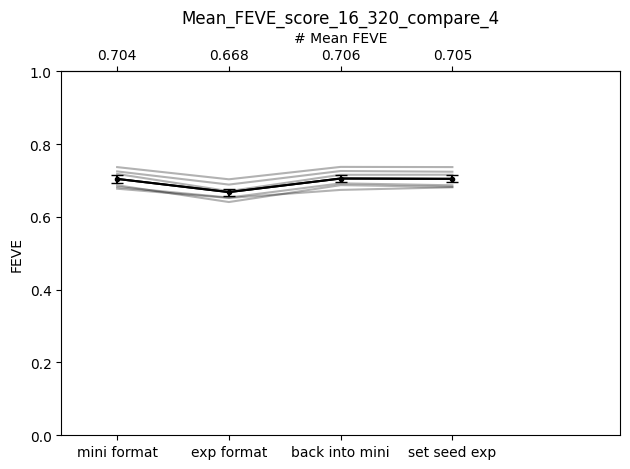

In [9]:
feve_scores = [feve_mice, feve_mice_exp, feve_mice_exp_transformed_back, feve_mice_exp_set_seed]
tick_labels = ['mini format', 'exp format', "back into mini", "set seed exp"]
title = "Mean_FEVE_score_16_320_compare_4"
plot_16_320(feve_scores, tick_labels, title)